In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from os import listdir
import matplotlib.pyplot as plt
from matplotlib import ticker
import scipy
import random
import itertools
from Generate_dataset import MyDataset
from utils import VisualizeGraphDataset, Describe, generate_tensor_list, get_connected_subgraph
import json
import statsmodels.api as sm
# ERGATFOLDERPATH = '/home/yingjie/Year_1/ERGAT/'
ERGATFOLDERPATH = '/home/yingjie_niu/Year_2/ERGAT-master/'
LOOKBACK = 22
SEED = -0.319

/anaconda3/envs/YJ_env/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Graph Dataset

In [4]:
dataset_fp = ERGATFOLDERPATH + "data/202209_202310/dynamic/Node3_Edge1_Normmin-max_Threshold0.0_WeightedEdgeCounter_text_True_2"
dataset = MyDataset(root=dataset_fp)
ReturnMatrix = pd.read_csv(ERGATFOLDERPATH + 'data/SP500/dataset202209-202310/ReturnMatrix.csv', index_col='Date')
with open(ERGATFOLDERPATH+"data/202209_202310/Comp_To_Node_Idx.json",'r') as f:
    Comp_To_Node_Idx = json.load(f)
print(f"Dataset period from {sorted(listdir(dataset_fp+'/processed'))[0]} to {sorted(listdir(dataset_fp+'/processed'))[-3]}")


Dataset period from data_2022-10-06.pt to data_2023-10-16.pt


In [5]:
ReturnMatrix = ReturnMatrix.loc['2022-10-06':'2023-10-16']

In [6]:
def historicalCorrelation(ReturnMatrix, comp1, comp2):
    """
    Input: ReturnMatrix, the company tickers of the two company to calculate
    Output: the Pearson Correlation Coefficient of the two companies per lookback window
    """
    # date = []
    # corr = []
    # for i in range(ReturnMatrix.shape[0]-LOOKBACK):
    #     returnSample = ReturnMatrix[[comp1,comp2]].iloc[i:i+LOOKBACK]
    #     corr.append(np.corrcoef(returnSample, rowvar=False)[0,1])
    #     date.append(ReturnMatrix.index[i+LOOKBACK])
    # corr = np.array(corr)
    hist_corr = ReturnMatrix[comp1].rolling(window=LOOKBACK).corr(ReturnMatrix[comp2])
    hist_corr = hist_corr[LOOKBACK-1:]
    corr = hist_corr.values
    date = hist_corr.index
    return corr, date

def getEdgeList(dataset, comp1, comp2, Comp_To_Node_Idx):
    """
    Return the edges between comp1 and comp2 as a list. If there is an edge, append the edge attribute, elses append 0. 
    """
    edge_list = []
    idx1, idx2 = Comp_To_Node_Idx[comp1], Comp_To_Node_Idx[comp2]
    for day in range(LOOKBACK, len(dataset)):
        g = dataset[day]

        # adj_matrix = EdgeIndex_To_AdjMatrix(graph=g, Comp_To_Node_Idx=Comp_To_Node_Idx)
        try:
            # edge = adj_matrix[comp1].loc[comp2]
            edge = g.edge_attr[np.logical_and(g.edge_index[0]==idx1, g.edge_index[1]==idx2) == 1]
            if edge.shape[0] != 0:
                edge = edge[-1].item()
            else:
                edge = np.nan
            edge_list.append(0) if np.isnan(edge) else edge_list.append(edge)
        except KeyError:
            edge_list.append(0)
    return edge_list

def DetectDrops(corr, edges, event_window=3):
    """
    Given the correlation series of two companies in the whole dataset period, and the edges built in the same period, this
    fnction returns the correlation maximum drop during the period, and the drop in the event period. 
    The event period is defined as follow:
        if there is an edge on day 't', event period = t-3 --> t+3
        if there are edges from day 't' to day 't+5', event period = 't-3' --> 't+8'
    This function also returns the rate between the drop in the event period and the max drop.
    This function also compairs the drop in the event period and the std in the whole period.
    """
    std = np.std(corr)
    max_drop = max(corr) - min(corr)

    event_periods_starts = []
    event_periods_ends = []
    x_prev = 0
    for i, x in enumerate(edges):
        if x != 0 and x_prev == 0:
            event_periods_starts.append(i)
        if x == 0 and x_prev != 0:
            event_periods_ends.append(i)
        x_prev = x
    if len(event_periods_starts) != len(event_periods_ends):
        event_periods_ends.append(len(edges)+1)
    if len(event_periods_starts) != len(event_periods_ends):
        raise IndexError(f'event_period_starts and event_period_ends length mis-match. {len(event_periods_starts), len(event_periods_ends)}')
    else:
        event_drops = {}
        for idx in range(len(event_periods_starts)):
            start = event_periods_starts[idx] - event_window
            end = event_periods_ends[idx] + event_window
            event_period_corr = corr[start:end]
            if len(event_period_corr) == 0:
                event_drop = 0
            else:
                event_drop = max(event_period_corr) - min(event_period_corr)
            # event_drop = max(event_period_corr) - min(event_period_corr)
            event_drops[(start, end)] = event_drop
    # print(f"Max Drop: {max_drop:.2f}, Std: {std:.2f}")
    ECR = []
    for event_period in event_drops:
        event_drop = event_drops[event_period]
        # print(f"Event Drop: {event_drop:.2f}, Drop Rate: {event_drop/max_drop:.2f}")
        EC_Te = 1 if event_drop/max_drop > std else 0
        ECR.append(EC_Te)
    return np.mean(ECR)

In [7]:
# def calculate_ECR(x):
#     Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
#     a = lambda x: [Node_Idx_To_Comp[x[0]], Node_Idx_To_Comp[x[1]]]
#     comp1 = a(x)[0]
#     comp2 = a(x)[1]
#     corr, date = historicalCorrelation(ReturnMatrix, comp1, comp2)
#     edgeList = getEdgeList(dataset, comp1, comp2, Comp_To_Node_Idx)
#     ECR = DetectDrops(corr, edgeList)
#     return ECR

# a = np.apply_along_axis(calculate_ECR, axis=0, arr=NodePairsHaveEdge.T)
# a

### 2. Take the graph of day t

[('ADI', 57), ('PM', 51), ('HBAN', 50), ('EW', 50), ('BBY', 44), ('MA', 43), ('LUV', 39), ('JNJ', 39), ('INCY', 37), ('NOC', 36), ('BDX', 35), ('CAG', 35), ('KR', 34), ('VRSN', 33), ('CNP', 33), ('ROP', 32), ('TSCO', 30), ('GRMN', 30), ('MTB', 29), ('GLW', 29), ('NI', 29), ('ULTA', 29), ('NTRS', 28), ('BAC', 27), ('NOV', 27), ('OMC', 27), ('UNH', 26), ('ROST', 26), ('AZO', 26), ('COP', 25), ('EMN', 25), ('COO', 25), ('FTI', 24), ('PWR', 24), ('VTR', 23), ('CME', 23), ('ORCL', 23), ('INTC', 23), ('COTY', 22), ('KHC', 22), ('SRCL', 21), ('ATVI', 21), ('AEP', 21), ('PG', 20), ('D', 20), ('KMB', 20), ('ETN', 20), ('MOS', 20), ('DFS', 19), ('PH', 18), ('NFLX', 18), ('UAL', 18), ('HLT', 18), ('ITW', 17), ('TGT', 17), ('XRX', 17), ('BAX', 17), ('APH', 17), ('LEN', 16), ('GPC', 16), ('ZBH', 16), ('FITB', 16), ('MAA', 16), ('MKC', 15), ('DVA', 15), ('RMD', 15), ('TJX', 14), ('DUK', 14), ('FLS', 14), ('EXPD', 14), ('PSX', 14), ('RF', 14), ('ZION', 14), ('ISRG', 13), ('PCAR', 13), ('FAST', 13), (

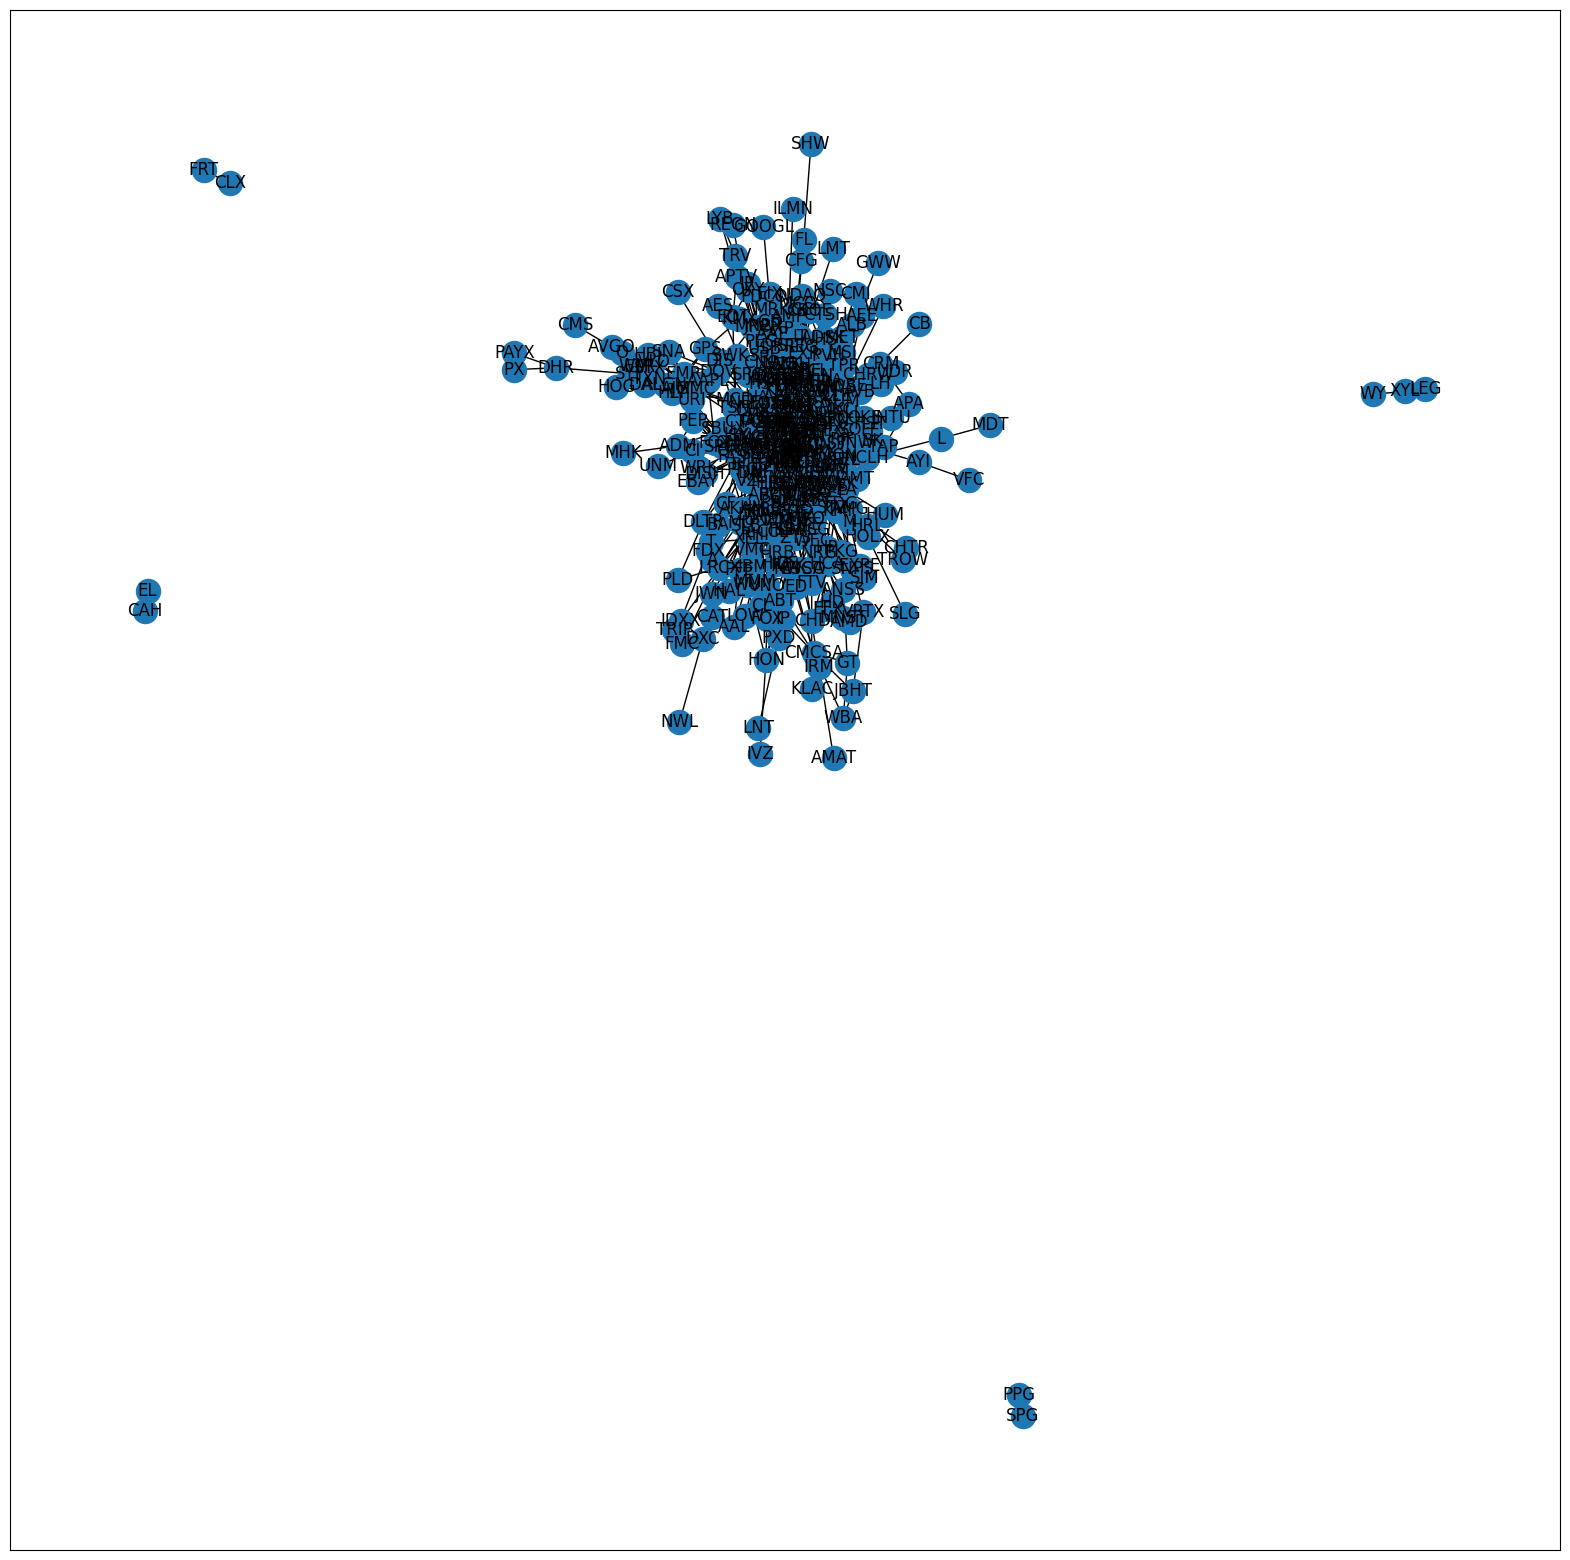

In [8]:
day_t = LOOKBACK+1
G_t = get_connected_subgraph(dataset[day_t])
VisualizeGraphDataset(dataset, day_t, subgraph=G_t)

In [10]:
dataset[0].edge_attr

tensor([[ 1.6658],
        [ 1.6658],
        [ 1.0850],
        ...,
        [ 0.5042],
        [-0.0766],
        [-0.0766]], dtype=torch.float64)

### 3. Statistic Sample T-test
N: the set of isolated nodes in the graph. 

M: the set of connected nodes in the graph.

* H0: $$ \frac{1}{NumOfEdges}\sum_{i=0}^M \sum_{j=0}^{Neighbour(i)} Corr(node_i,node_j) = 0$$

or


* H0: $$ \frac{1}{NumOfEdges}\sum_{i=0}^M \sum_{j=0}^{Neighbour(i)} Corr(node_i,node_j) !=  \frac{1}{NumOfEdges}\sum_{i=0}^N \sum_{j=0}^{N} Corr(node_i,node_j)$$



In [6]:
def historicalCorrelation(ReturnMatrix, comp1, comp2):
    """
    Input: ReturnMatrix, the company tickers of the two company to calculate
    Output: the Pearson Correlation Coefficient of the two companies per lookback window
    """
    # date = []
    # corr = []
    # for i in range(ReturnMatrix.shape[0]-LOOKBACK):
    #     returnSample = ReturnMatrix[[comp1,comp2]].iloc[i:i+LOOKBACK]
    #     corr.append(np.corrcoef(returnSample, rowvar=False)[0,1])
    #     date.append(ReturnMatrix.index[i+LOOKBACK])
    # corr = np.array(corr)
    hist_corr = ReturnMatrix[comp1].rolling(window=LOOKBACK).corr(ReturnMatrix[comp2])
    hist_corr = hist_corr[LOOKBACK-1:]
    corr = hist_corr.values
    date = hist_corr.index
    return corr, date

def historicalReturnDiff(ReturnMatrix, comp1, comp2):
    """
    Input: ReturnMatrix, the company tickers of the two company to calculate
    Output: the return difference of the two companies
    """
    date = []
    diff = []
    for i in range(ReturnMatrix.shape[0]-LOOKBACK):
        diff.append(ReturnMatrix[comp1].iloc[i] - ReturnMatrix[comp2].iloc[i])
        date.append(ReturnMatrix.index[i+LOOKBACK])
    diff = np.array(diff)
    return diff, date

def plotHistoricalCorr(date, corr):
    plt.figure(figsize=(20,5))
    plt.plot(date, corr)
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))

# def ConnectedCorrDiff(G_t, day_t, Comp_To_Node_Idx, ReturnMatrix):
#     """
#     Input: 
#     G_t: Graph of day t
#     day t: day t 
#     Comp_To_Node_Idx : a dictionary from company to node index
#     ReturnNatrix : return matrix
    
#     Output: 
#     A list of correlations difference of each pair of directly connected nodes in the G_t
#     The correlation difference = the correlation after this edge were built - the correlation before this edge where built
#     """
#     Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
#     edge_index = G_t.edge_index
#     # iterate all edges and calculate the correlation of node pairs of each edge
#     # store the correlations difference of each pair of connected nodes in corr_diff_li
#     corr_diff_li = []
#     for i in range(edge_index.shape[1]):
#         node1 = Node_Idx_To_Comp[edge_index[:,i][0]]
#         node2 = Node_Idx_To_Comp[edge_index[:,i][1]]
#         hist_corr, _ = historicalCorrelation(ReturnMatrix, node1, node2)
#         # prev_corr, post_corr = hist_corr[day_t - LOOKBACK], hist_corr[day_t - LOOKBACK + 2]
#         prev_corr, post_corr = hist_corr[day_t - LOOKBACK], hist_corr[day_t]
#         # print(node1, node2,prev_corr, post_corr)
#         corr_diff_li.append(post_corr-prev_corr)
        
#     return corr_diff_li


def ConnectedCorrDiff(G_t, day_t, Comp_To_Node_Idx, ReturnMatrix):
    """
    Input: 
    G_t: Graph of day t
    day t: day t 
    Comp_To_Node_Idx : a dictionary from company to node index
    ReturnNatrix : return matrix
    
    Output: 
    A list of correlations difference of each pair of directly connected nodes in the G_t
    The correlation difference = the correlation after this edge were built - the correlation before this edge where built
    """
    # 自定义函数
    def custom_function(x):
        Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
        a = lambda x: [Node_Idx_To_Comp[x[0]], Node_Idx_To_Comp[x[1]]]
        node1 = a(x)[0]
        node2 = a(x)[1]
        hist_corr = ReturnMatrix[node1].rolling(window=LOOKBACK).corr(ReturnMatrix[node2])
        # hist_corr, _ = historicalCorrelation(ReturnMatrix, node1, node2)
        prev_corr, post_corr = hist_corr[day_t - 1], hist_corr[day_t + LOOKBACK-1]

        return post_corr-prev_corr


    # 将相互链接的节点对的edge_index赋值为一个二维数组
    original_array = np.array(G_t.edge_index)

    # 对每一列应用自定义函数
    corr_diff_li = np.apply_along_axis(custom_function, axis=0, arr=original_array)
            
    return corr_diff_li


def IsolatedCorrDiff(G_t, G_t_node_idx, Comp_To_Node_Idx, ReturnMatrix):
    """
    Input:
    Output: 
    """
    Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
    node_idx = torch.tensor(list(Comp_To_Node_Idx.values()))
    isolated_node_idx = node_idx[~torch.isin(node_idx, G_t_node_idx)]
    # iterate all edges and calculate the correlation of node pairs of each edge
    # store the correlations difference of each pair of connected nodes in corr_diff_li
    corr_diff_li = []
    pairs = []
    for i in range(G_t.edge_index.shape[1]):
        random_index = torch.randint(0, isolated_node_idx.shape[0], (1,2))[0]
        random_index_set = set(np.array(random_index))
        if random_index_set not in pairs:
            pairs.append(random_index_set)
            node1 = Node_Idx_To_Comp[isolated_node_idx[random_index[0]]]
            node2 = Node_Idx_To_Comp[isolated_node_idx[random_index[1]]]
            # hist_corr, _ = historicalCorrelation(ReturnMatrix, node1, node2)
            # # prev_corr, post_corr = hist_corr[day_t - LOOKBACK], hist_corr[day_t - LOOKBACK + 2]
            # prev_corr, post_corr = hist_corr[day_t - LOOKBACK], hist_corr[day_t]

            hist_corr = ReturnMatrix[node1].rolling(window=LOOKBACK).corr(ReturnMatrix[node2])
            # hist_corr, _ = historicalCorrelation(ReturnMatrix, node1, node2)
            prev_corr, post_corr = hist_corr[day_t - 1], hist_corr[day_t + LOOKBACK-1]
            
            corr_diff_li.append(post_corr-prev_corr)
    return corr_diff_li

def SingleSampleTtest(data, mean):
    """
    One sample T test
    """
    return scipy.stats.ttest_1samp(data,mean)

In [18]:
import numpy as np
corr_diff_li = []
# 自定义函数
def custom_function(x):
    Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
    a = lambda x: [Node_Idx_To_Comp[x[0]], Node_Idx_To_Comp[x[1]]]
    node1 = a(x)[0]
    node2 = a(x)[1]
    hist_corr = ReturnMatrix[node1].rolling(window=LOOKBACK).corr(ReturnMatrix[node2])
    # hist_corr, _ = historicalCorrelation(ReturnMatrix, node1, node2)
    prev_corr, post_corr = hist_corr[day_t - 1], hist_corr[day_t + LOOKBACK-1]
    corr_diff_li.append(post_corr-prev_corr)
    return post_corr-prev_corr


# 创建一个二维NumPy数组
original_array = np.array(G_t.edge_index)

# 对每一列应用自定义函数
result_array_conn = np.apply_along_axis(custom_function, axis=0, arr=original_array)

print(result_array_conn)

[0.10460892 0.10460892 0.18483542 ... 0.01767018 0.16524223 0.16524223]


In [113]:
connectedCorrDiff = ConnectedCorrDiff(G_t, day_t, Comp_To_Node_Idx, ReturnMatrix)
isolatedCorrDiff = IsolatedCorrDiff(G_t, G_t_node_idx, Comp_To_Node_Idx, ReturnMatrix)

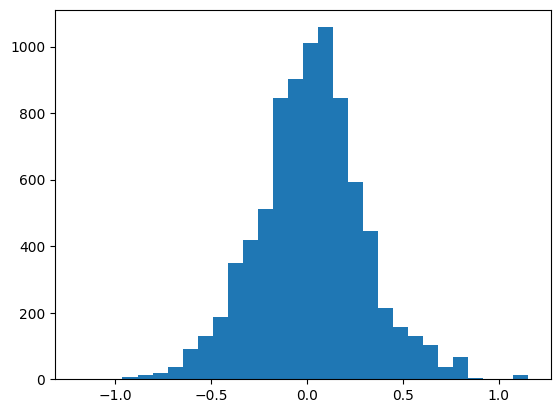

In [114]:
plt.hist(connectedCorrDiff, bins=30)
plt.show()

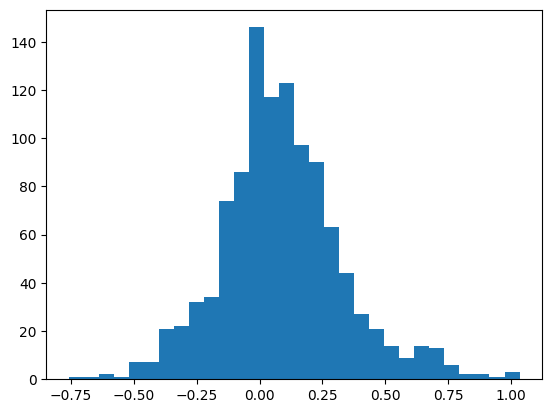

In [115]:
plt.hist(isolatedCorrDiff, bins=30)
plt.show()

In [116]:
# Single sample T test on the connected nodes correlation difference
stat, p = SingleSampleTtest(data=connectedCorrDiff,mean=0)
print('Connected Nodes: pvalue = ',p)
# Single sample T test on the isolated nodes correlation difference
stat, p = SingleSampleTtest(data=isolatedCorrDiff,mean=0)
print('Isolated Nodes: pvalue = ',p)

Connected Nodes: pvalue =  7.900267763888141e-11
Isolated Nodes: pvalue =  5.79849702092959e-31


In [117]:
print(scipy.stats.levene(connectedCorrDiff, isolatedCorrDiff))
print(scipy.stats.ttest_ind(connectedCorrDiff, isolatedCorrDiff, equal_var=False, alternative="less"))

LeveneResult(statistic=30.763389368770437, pvalue=2.994916434525202e-08)
Ttest_indResult(statistic=-8.540455709676698, pvalue=1.6388262823939218e-17)


In [119]:
a = scipy.stats.ttest_ind(result_array_conn, result_array_isol, equal_var=False, alternative="less")
a.pvalue < 0.01

True

上面试验结果说明，在alpha=0.01显著性水平下，connected nodes的相关性变化 小于 isolated nodes的相关性变化

Now we repeat the test for 10 times since we randomly sampled num_edges pairs of isolated nodes. 

We first repeat 10 times random sampling and see whether the correlation difference of each group of isolated nodes are the same. 

We then repeat 10 times random sampling and see whether the correlation difference of each group of isolated nodes are the same as it of connected nodes. 

In [ ]:
p_list = []
for i in range(10):
    isolatedCorrDiff_2 = IsolatedCorrDiff(G_t, G_t_node_idx, Comp_To_Node_Idx, ReturnMatrix)
    _, varp = scipy.stats.levene(isolatedCorrDiff, isolatedCorrDiff_2)
    if varp >0.05:  #满足方差齐性
        _, p = scipy.stats.ttest_ind(isolatedCorrDiff, isolatedCorrDiff_2)
    else:
        _, p = scipy.stats.ttest_ind(isolatedCorrDiff, isolatedCorrDiff_2, equal_var=False)
    p_list.append(p)
print("10 repeating experiments p value: ",p_list)
print("Average p value: ",np.mean(p_list))


10 repeating experiments p value:  [0.9965824526137477, 0.9937653759895856, 0.9856770694642394, 0.9875249781109354, 0.989295622660675, 0.9937653759895866, 0.9868498819719499, 0.9973150011279222, 1.0, 1.0]
Average p value:  0.9930775757928642


In [ ]:
p_list = []
for i in range(10):
    isolatedCorrDiff_2 = IsolatedCorrDiff(G_t, G_t_node_idx, Comp_To_Node_Idx, ReturnMatrix)
    _, varp = scipy.stats.levene(isolatedCorrDiff, isolatedCorrDiff_2)
    if varp >0.05:  #满足方差齐性
        _, p = scipy.stats.ttest_ind(connectedCorrDiff, isolatedCorrDiff_2)
    else:
        _, p = scipy.stats.ttest_ind(connectedCorrDiff, isolatedCorrDiff_2, equal_var=False, alternative='less')
    p_list.append(p)
print("10 repeating experiments p value: ",p_list)
print("Average p value: ",np.mean(p_list))

10 repeating experiments p value:  [2.072206196774397e-17, 3.5166020546167437e-17, 1.767893945690273e-17, 3.4848362427179363e-17, 2.1509673737796455e-17, 2.234624140997671e-17, 2.335713082225402e-17, 1.7122641898945522e-17, 1.4203314564773966e-17, 1.8225109870913644e-17]
Average p value:  2.2517949670265386e-17


Through 10 repeating experiments, we found that at alpha=0.1 significance level, the correlation difference of connected nodes are not equal to the correlation difference of isolated nodes. 

But the correlation difference of different group of isolated nodes are equal. The results suggest that the built edges is meaningful to some extend. But we need more proof. 


In [ ]:
for day in range(LOOKBACK, len(dataset)):
    G_t, G_t_node_idx = get_connected_subgraph(dataset[day])
    connectedCorrDiff = ConnectedCorrDiff(G_t, day_t, Comp_To_Node_Idx, ReturnMatrix)
    isolatedCorrDiff = IsolatedCorrDiff(G_t, G_t_node_idx, Comp_To_Node_Idx, ReturnMatrix)
    print("Single Sample T test: ")
    stat, p = SingleSampleTtest(data=connectedCorrDiff,mean=0)
    print('Connected Nodes: pvalue = ',p)
    stat, p = SingleSampleTtest(data=isolatedCorrDiff,mean=0)
    print('Isolated Nodes: pvalue = ',p)
    print("\nTwo Sample T test: \n")
    # print(scipy.stats.levene(connectedCorrDiff, isolatedCorrDiff))
    # _, varp = scipy.stats.levene(connectedCorrDiff, isolatedCorrDiff)
    # if varp >0.05:  #满足方差齐性
    #     print(scipy.stats.ttest_ind(connectedCorrDiff, isolatedCorrDiff))
    # else:
    print(scipy.stats.ttest_ind(connectedCorrDiff, isolatedCorrDiff, equal_var=False, alternative='less'))
    

Single Sample T test: 
Connected Nodes: pvalue =  2.937858068094992e-11
Isolated Nodes: pvalue =  1.5923824662846313e-12

Two Sample T test: 

Ttest_indResult(statistic=-4.040678254419164, pvalue=2.9643749678253978e-05)
Single Sample T test: 
Connected Nodes: pvalue =  0.004648419781261764
Isolated Nodes: pvalue =  1.3267566284254453e-26

Two Sample T test: 

Ttest_indResult(statistic=-9.141039664098956, pvalue=2.5440976853865366e-19)
Single Sample T test: 
Connected Nodes: pvalue =  0.2033943730567369
Isolated Nodes: pvalue =  1.3288949936351256e-30

Two Sample T test: 

Ttest_indResult(statistic=-9.976018635761502, pvalue=1.0115304825941967e-22)
Single Sample T test: 
Connected Nodes: pvalue =  0.5036765628407068
Isolated Nodes: pvalue =  2.1766185557900127e-27

Two Sample T test: 

Ttest_indResult(statistic=-10.214017793617863, pvalue=9.675597073389132e-24)
Single Sample T test: 
Connected Nodes: pvalue =  9.64817786030649e-07
Isolated Nodes: pvalue =  6.211863057192456e-17

Two Sam


## 4. Correlation Distribution and At Tail after G

For the graph G_t, if there is an edge between NodeA and NodeB, then we find the distribution of the correlation of NodeA and NodeB. Assuming the correlation satisfies normal distribution, if the correlation after G_t falls on the tail of the distribution, it means this edge lead to a great changing of the relation of the two companies.

In [76]:
def EdgeIndex_To_AdjMatrix(graph, Comp_To_Node_Idx):
    """
    Input: graph as type torch_geometric.data.data.Data, Comp_To_Node_Idx as type dict
    Output: adjacency matrix graph
    """
    edge_index, edge_attr = graph.edge_index, graph.edge_attr
    nodes = torch.tensor(np.array(list(set(np.array(edge_index[0])))))
    Node_Idx_To_Comp = list(Comp_To_Node_Idx.keys())
    num_edges = edge_index.shape[1]
    adj_matrix = pd.DataFrame(columns=[Node_Idx_To_Comp[node] for node in nodes], index=[Node_Idx_To_Comp[node] for node in nodes])
    for i in range(num_edges):
        source, target = edge_index[:,i]
        source = Node_Idx_To_Comp[source.item()]
        target = Node_Idx_To_Comp[target.item()]
        attr = edge_attr[i].item()
        adj_matrix[source].loc[target]=attr
        
    return adj_matrix


def getEdgeList(comp1, comp2, Comp_To_Node_Idx):
    """
    Return the edges between comp1 and comp2 as a list. If there is an edge, append the edge attribute, elses append 0. 
    """
    edge_list = []
    idx1, idx2 = Comp_To_Node_Idx[comp1], Comp_To_Node_Idx[comp2]
    for day in range(LOOKBACK, len(dataset)):
        g = dataset[day]

        # adj_matrix = EdgeIndex_To_AdjMatrix(graph=g, Comp_To_Node_Idx=Comp_To_Node_Idx)
        try:
            # edge = adj_matrix[comp1].loc[comp2]
            edge = g.edge_attr[np.logical_and(g.edge_index[0]==idx1, g.edge_index[1]==idx2) == 1]
            if edge.shape[0] != 0:
                edge = edge[-1].item()
            else:
                edge = np.nan
            # edge_list.append(0) if np.isnan(edge) else edge_list.append(edge)
            edge_list.append(0) if np.isnan(edge) else edge_list.append(1)
        except KeyError:
            edge_list.append(0)
    return edge_list

def plotEdge(date, edge_list, corr):
    plt.figure(figsize=(8,5))
    plt.scatter(date, edge_list)
    plt.plot(date, corr)
    plt.xlabel('Date')
    plt.ylabel('AAPL-JPM Return Correlation')
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))

In [9]:
np.logical_and(G_t.edge_index[0]==136, G_t.edge_index[1]==369) == 1
G_t.edge_attr[np.logical_and(G_t.edge_index[0]==136, G_t.edge_index[1]==369) == 1][-1].item()

IndexError: index -1 is out of bounds for dimension 0 with size 0

### Define two companies, get the correlation of these two companies in the dataset period

Plot the correlation graph and the edges built in the corresponding period. Align the edges and the correlation changes.

In [10]:
ReturnMatrix.columns

Index(['HIG', 'RSG', 'BK', 'MAT', 'TSCO', 'WBA', 'AVB', 'ISRG', 'AMAT', 'SLG',
       ...
       'WDC', 'PPL', 'PSA', 'MSFT', 'ACN', 'C', 'V', 'PRGO', 'CDNS', 'AMGN'],
      dtype='object', length=431)

Mean:  0.36002170357728674 Std:  0.18441331284558155


(array([ 3.,  3.,  3.,  4.,  4.,  3.,  8.,  5.,  6., 11., 12., 11., 17.,
         8., 14., 17., 17., 12., 12., 13., 10., 13., 12., 10.,  9.]),
 array([-0.09882197, -0.06788992, -0.03695787, -0.00602583,  0.02490622,
         0.05583826,  0.08677031,  0.11770236,  0.1486344 ,  0.17956645,
         0.2104985 ,  0.24143054,  0.27236259,  0.30329463,  0.33422668,
         0.36515873,  0.39609077,  0.42702282,  0.45795487,  0.48888691,
         0.51981896,  0.550751  ,  0.58168305,  0.6126151 ,  0.64354714,
         0.67447919]),
 <BarContainer object of 25 artists>)

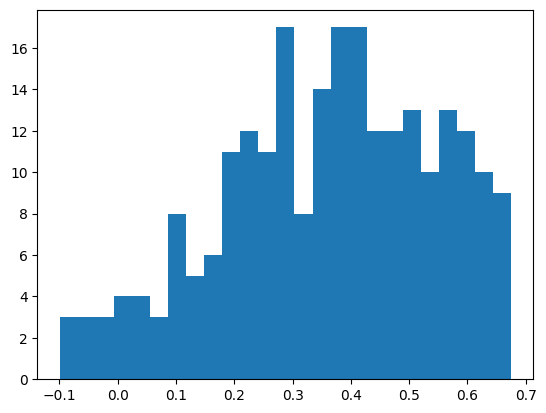

In [8]:
comp1, comp2 = 'AAPL', 'JPM'
corr_HIG_AON, date = historicalCorrelation(ReturnMatrix, comp1, comp2)
returndiff_HIG_AON, date = historicalReturnDiff(ReturnMatrix, comp1, comp2)
edges_HIG_AON = getEdgeList(comp1, comp2, Comp_To_Node_Idx)
mu, std = scipy.stats.norm.fit(corr_HIG_AON)
print('Mean: ',mu, "Std: ",std)
plt.hist(corr_HIG_AON, bins=25)

In [9]:
date[90:120]

['2023-03-20',
 '2023-03-21',
 '2023-03-22',
 '2023-03-23',
 '2023-03-24',
 '2023-03-27',
 '2023-03-28',
 '2023-03-29',
 '2023-03-30',
 '2023-03-31',
 '2023-04-03',
 '2023-04-04',
 '2023-04-05',
 '2023-04-06',
 '2023-04-10',
 '2023-04-11',
 '2023-04-12',
 '2023-04-13',
 '2023-04-14',
 '2023-04-17',
 '2023-04-18',
 '2023-04-19',
 '2023-04-20',
 '2023-04-21',
 '2023-04-24',
 '2023-04-25',
 '2023-04-26',
 '2023-04-27',
 '2023-04-28',
 '2023-05-01']

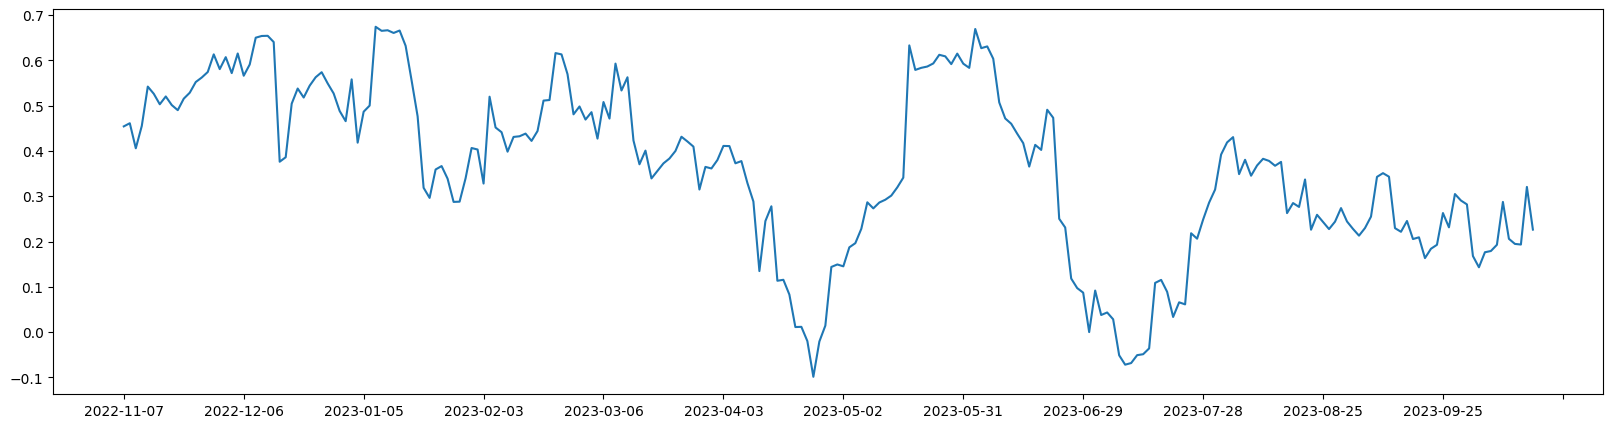

In [10]:
plotHistoricalCorr(date, corr_HIG_AON[:-1])

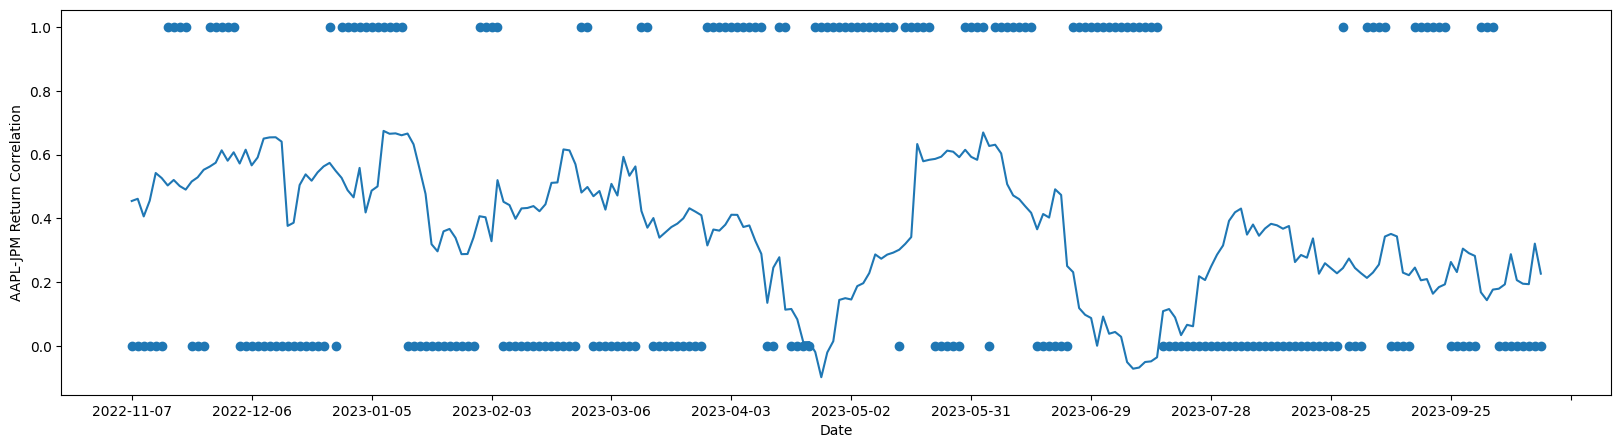

In [73]:
plotEdge(date, edges_HIG_AON, corr_HIG_AON[:-1])

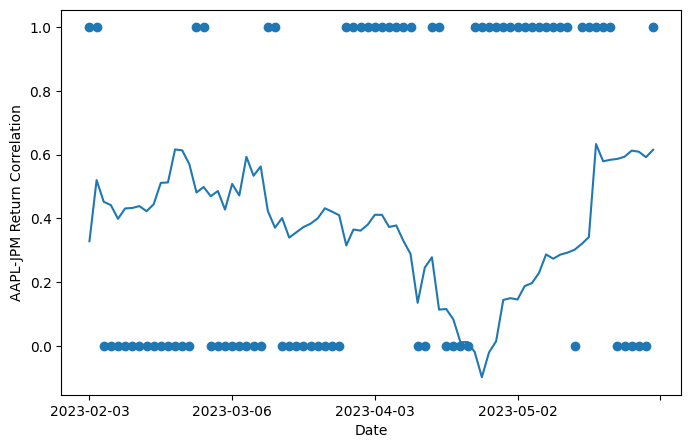

In [78]:
plotEdge(date[60:140], edges_HIG_AON[60:140], corr_HIG_AON[60:140])

In [79]:
import os
comp_list = os.listdir('../data/SP500/dataset202209-202310/news_with_related_company')
aapl = []
for comp in tqdm(comp_list):
    if comp.split('.')[1] == 'csv':
        file = pd.read_csv('../data/SP500/dataset202209-202310/news_with_related_company/'+comp)
    file.columns = ['ID','Firm','Date','Title','Source','Link','NAN','Type','RelatedCompany','Text']
    # try:
    #     start= min(file.index[file['Date'] =='2023-3-15'])
    # except ValueError:
        
    #     start=min(file.index[file['Date'] =='2023-3-16'])
    # try:
    #     end= max(file.index[file['Date'] =='2023-4-25'])
    # except ValueError:
    #     end=max(file.index[file['Date'] =='2023-4-26'])
    
    start, end = [1383,1938]
    file = file.iloc[start:end]
    temp = file.loc[file.index[file['RelatedCompany'].apply(lambda x: 'AAPL' in x)]]
    temp = temp.loc[temp.index[temp['RelatedCompany'].apply(lambda x: 'JPM' in x)]]
    if len(temp) != 0:
        if len(aapl) == 0:
            aapl = temp
        else:
            aapl = pd.concat([aapl, temp])


100%|██████████| 466/466 [00:22<00:00, 20.57it/s]


In [80]:
aapl

,ID,Firm,Date,Title,Source,Link,NAN,Type,RelatedCompany,Text
1455,86dbb7d4-8da2-31d1-b7fa-748170f05024,HD,2023-3-28,CIBC introduces additional Canadian Depositary...,CNW Group,https://finance.yahoo.com/news/cibc-introduces...,1680004800,STORY,"['META', 'KO', 'ABBV', 'JPM', 'MSFT', 'AAPL', ...",[Expanded CDR lineup provides more opportuniti...
1467,86dbb7d4-8da2-31d1-b7fa-748170f05024,HD,2023-3-29,CIBC introduces additional Canadian Depositary...,CNW Group,https://finance.yahoo.com/news/cibc-introduces...,1680004800,STORY,"['META', 'KO', 'ABBV', 'JPM', 'MSFT', 'AAPL', ...",[Expanded CDR lineup provides more opportuniti...
1478,86dbb7d4-8da2-31d1-b7fa-748170f05024,HD,2023-3-30,CIBC introduces additional Canadian Depositary...,CNW Group,https://finance.yahoo.com/news/cibc-introduces...,1680004800,STORY,"['META', 'KO', 'ABBV', 'JPM', 'MSFT', 'AAPL', ...",[Expanded CDR lineup provides more opportuniti...
1463,fc107089-985e-3a94-994f-9f75e6d5571b,USB,2023-3-30,Why Banks Are Waging a Digital-Wallet War With...,WSJ,https://finance.yahoo.com/video/why-banks-wagi...,1680108960,VIDEO,"['GOOG', 'GOOGL', 'JPM', 'PYPL', 'AAPL', 'COF'...",[Banks are worried they’re losing ground to te...
1475,fc107089-985e-3a94-994f-9f75e6d5571b,USB,2023-3-31,Why Banks Are Waging a Digital-Wallet War With...,WSJ,https://finance.yahoo.com/video/why-banks-wagi...,1680108960,VIDEO,"['GOOG', 'GOOGL', 'JPM', 'PYPL', 'AAPL', 'COF'...",[Banks are worried they’re losing ground to te...
...,...,...,...,...,...,...,...,...,...,...
1613,24f7d302-31cb-4e0f-beca-dda816f229b2,UNP,2023-4-26,The economic mood and other investing stories ...,Yahoo Finance,https://finance.yahoo.com/news/the-economic-mo...,1682166604,STORY,"['AXP', 'JBHT', 'META', 'NFLX', 'AN', 'CLX', '...",[This week was hardly bullish. Here's what inv...
1622,24f7d302-31cb-4e0f-beca-dda816f229b2,UNP,2023-4-27,The economic mood and other investing stories ...,Yahoo Finance,https://finance.yahoo.com/news/the-economic-mo...,1682166604,STORY,"['AXP', 'JBHT', 'META', 'NFLX', 'AN', 'CLX', '...",[This week was hardly bullish. Here's what inv...
1457,86dbb7d4-8da2-31d1-b7fa-748170f05024,CSCO,2023-3-28,CIBC introduces additional Canadian Depositary...,CNW Group,https://finance.yahoo.com/news/cibc-introduces...,1680004800,STORY,"['META', 'KO', 'ABBV', 'JPM', 'MSFT', 'AAPL', ...",[Expanded CDR lineup provides more opportuniti...
1468,86dbb7d4-8da2-31d1-b7fa-748170f05024,CSCO,2023-3-29,CIBC introduces additional Canadian Depositary...,CNW Group,https://finance.yahoo.com/news/cibc-introduces...,1680004800,STORY,"['META', 'KO', 'ABBV', 'JPM', 'MSFT', 'AAPL', ...",[Expanded CDR lineup provides more opportuniti...


In [93]:
aapl[aapl['Title'].apply(lambda x: 'Dow Jones Rises' in x)]['Link'][1663]

'https://finance.yahoo.com/m/734bb499-4ecc-398d-bf29-b8cf6e861517/dow-jones-rises-as-jpmorgan.html'

In [86]:
aapl_unique = aapl[['Date','RelatedCompany','Title','Text']]
aapl_unique = aapl_unique.drop_duplicates()
aapl_unique.sort_values(by='Date').to_csv('../outputs/AAPL_JPM_0328_0607.csv')

In [84]:
aapl_unique[['Title','Text']].drop_duplicates()

,Title,Text
1455,CIBC introduces additional Canadian Depositary...,[Expanded CDR lineup provides more opportuniti...
1463,Why Banks Are Waging a Digital-Wallet War With...,[Banks are worried they’re losing ground to te...
1668,Warren Buffett Q&A: 3 things to watch,[Warren Buffett will take center stage on Satu...
1833,15 Best Blue Chip Stocks To Buy According to H...,"[In this article, we will take a look at the 1..."
1504,How Warren Buffett could steal the show in the...,[This article first appeared in the Morning Br...
1617,The economic mood and other investing stories ...,[This week was hardly bullish. Here's what inv...
1920,Dow Jones Today: Apple Headset Can’t Lift Index,"[The Dow Jones Industrial Average fell 0.6%, o..."
1620,The economic mood and other investing stories ...,[This week was hardly bullish. Here's what inv...
1758,The 7 Best Meme Stocks to Buy for 2023,[Meme stocks comprise a wide spectrum of compa...
1663,Dow Jones Rises As JPMorgan Buys Failed First ...,"[The Dow Jones rose Monday morning, as JPMorga..."


###
在我们的数据集中，关于某两个公司的新闻通常在一段时间内高频出现，而在其他时间内则一条都没有。而在新闻高频出现的那一段时间T内，如果我们能观测到corr随之有显著变化，则说明某事发生了。那么如果我们在T内只考虑某一天的edge以及当天前后corr的变化，似乎不能有效反应这个edge的有用性。E.g. 公司A和B的correlation mean 是0.7， 当事件x发生，在一段时间内corr变成了0.3左右，那么如果我们抽出其中一天进行观测，很有可能得到该天前后的corr分别为0.33和0.31， 该edge前后的corr变化不显著是否说明该edge没用呢？显然不。如果我们可以综合考虑事件x发生后这一段时间的corr和其他时间段的corr，我们就会观测到明显的变化， 从而证明这段时间内的edge都是有意义的。

现在的问题是：如何设计一个指标使得我们能捕捉到一段时间内的corr(s)与整体corr(s)的差异?

能否取事件发生前后的一段时间T，计算T内的max-min 与整个数据集时间段内的correlation的max-min比较，或者与std比较。

1. 如果T(max-min)>std, 则说明基于事件发生而建立的edge反映了correlation的显著变化。
2. 如果T(max-min)>n*(max-min), 则说明基于事件发生而建立的edge反映了correlation的显著变化。

In [20]:
def DetectDrops(corr, edges, event_window=3):
    """
    Given the correlation series of two companies in the whole dataset period, and the edges built in the same period, this
    fnction returns the correlation maximum drop during the period, and the drop in the event period. 
    The event period is defined as follow:
        if there is an edge on day 't', event period = t-3 --> t+3
        if there are edges from day 't' to day 't+5', event period = 't-3' --> 't+8'
    This function also returns the rate between the drop in the event period and the max drop.
    This function also compairs the drop in the event period and the std in the whole period.
    """
    std = np.std(corr)
    max_drop = max(corr) - min(corr)

    event_periods_starts = []
    event_periods_ends = []
    x_prev = 0
    for i, x in enumerate(edges):
        if x != 0 and x_prev == 0:
            event_periods_starts.append(i)
        if x == 0 and x_prev != 0:
            event_periods_ends.append(i)
        x_prev = x
    if len(event_periods_starts) != len(event_periods_ends):
        event_periods_ends.append(len(edges)+1)
    if len(event_periods_starts) != len(event_periods_ends):
        raise IndexError(f'event_period_starts and event_period_ends length mis-match. {len(event_periods_starts), len(event_periods_ends)}')
    else:
        event_drops = {}
        for idx in range(len(event_periods_starts)):
            start = event_periods_starts[idx] - event_window
            end = event_periods_ends[idx] + event_window
            event_period_corr = corr[start:end]
            if len(event_period_corr) == 0:
                event_drop = 0
            else:
                event_drop = max(event_period_corr) - min(event_period_corr)
            event_drops[(start, end)] = event_drop
    print(f"Max Drop: {max_drop:.2f}, Std: {std:.2f}")
    ECR = []
    for event_period in event_drops:
        event_drop = event_drops[event_period]
        print(f"Event Drop: {event_drop:.2f}, Drop Rate: {event_drop/max_drop:.2f}")
        EC_Te = 1 if event_drop/max_drop > std else 0
        ECR.append(EC_Te)
    return np.mean(ECR)

In [87]:
DetectDrops(corr_HIG_AON, edges_HIG_AON)

Max Drop: 0.89, Std: 0.18
Event Drop: 0.00, Drop Rate: 0.00
Event Drop: 0.11, Drop Rate: 0.13
Event Drop: 0.06, Drop Rate: 0.07
Event Drop: 0.05, Drop Rate: 0.05
Event Drop: 0.04, Drop Rate: 0.05
Event Drop: 0.03, Drop Rate: 0.04
Event Drop: 0.30, Drop Rate: 0.34
Event Drop: 0.30, Drop Rate: 0.34
Event Drop: 0.15, Drop Rate: 0.17
Event Drop: 0.04, Drop Rate: 0.05
Event Drop: 0.15, Drop Rate: 0.17
Event Drop: 0.13, Drop Rate: 0.14
Event Drop: 0.04, Drop Rate: 0.04
Event Drop: 0.03, Drop Rate: 0.03
Event Drop: 0.10, Drop Rate: 0.11
Event Drop: 0.09, Drop Rate: 0.10
Event Drop: 0.16, Drop Rate: 0.18
Event Drop: 0.04, Drop Rate: 0.04
Event Drop: 0.15, Drop Rate: 0.17
Event Drop: 0.12, Drop Rate: 0.13
Event Drop: 0.02, Drop Rate: 0.02
Event Drop: 0.04, Drop Rate: 0.05
Event Drop: 0.04, Drop Rate: 0.05
Event Drop: 0.13, Drop Rate: 0.14
Event Drop: 0.13, Drop Rate: 0.14
Event Drop: 0.02, Drop Rate: 0.02
Event Drop: 0.08, Drop Rate: 0.08
Event Drop: 0.14, Drop Rate: 0.16
Event Drop: 0.20, Drop

0.16393442622950818

### Return1 - Return2


In [21]:
plotHistoricalCorr(date, returndiff_HIG_AON)


NameError: name 'date' is not defined

Mean:  0.0011606025717811217 Std:  0.01712263557523061


(array([ 2.,  3.,  5., 14., 22., 47., 66., 40., 25.,  5.,  2.,  1.,  1.,
         1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-0.04539483, -0.0381224 , -0.03084996, -0.02357752, -0.01630508,
        -0.00903264, -0.0017602 ,  0.00551224,  0.01278467,  0.02005711,
         0.02732955,  0.03460199,  0.04187443,  0.04914687,  0.05641931,
         0.06369174,  0.07096418,  0.07823662,  0.08550906,  0.0927815 ,
         0.10005394,  0.10732638,  0.11459881,  0.12187125,  0.12914369,
         0.13641613]),
 <BarContainer object of 25 artists>)

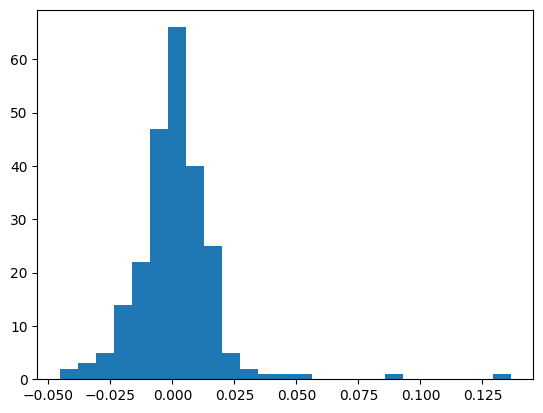

In [ ]:
mu, std = scipy.stats.norm.fit(returndiff_HIG_AON)
print('Mean: ',mu, "Std: ",std)
plt.hist(returndiff_HIG_AON, bins=25)

In [ ]:
bool_edge = []
for i in edges_HIG_AON:
    if i==0:
        bool_edge.append(False)
    else:
        bool_edge.append(True)
returndiff_HIG_AON[bool_edge]

array([-1.40217754e-02,  5.34452629e-03, -8.63967082e-03,  2.43571608e-03,
       -6.34875604e-03,  1.73752066e-02,  4.09639231e-03,  3.31710698e-03,
       -1.77918134e-02, -3.69345322e-02, -1.28192791e-02,  3.30810326e-03,
        5.87648827e-03,  5.49300406e-03, -1.74820685e-02,  5.69995155e-04,
        3.44352121e-03, -2.37487111e-03, -6.05119215e-04,  1.45134360e-02,
       -6.65457692e-03,  1.35627451e-02,  6.18478176e-03, -2.42093579e-02,
        2.95959882e-02, -1.28035962e-03,  1.17837846e-02,  2.30200233e-03,
        3.23802343e-03, -9.99075418e-04,  9.85231195e-03,  5.53310156e-03,
       -1.30844239e-02,  2.80256770e-03,  7.42845867e-04, -1.10331253e-03,
        6.54424845e-03,  7.69323796e-03, -1.54941634e-04,  2.03984891e-02,
       -6.98585800e-04, -3.20615521e-03,  1.00248235e-02, -2.99538038e-02,
       -1.05057052e-02,  6.34684330e-03,  1.36038102e-02,  6.10083391e-03,
       -2.99755332e-03, -2.85974365e-03, -4.37448018e-03, -6.13166115e-03,
        1.21128037e-02, -

In [ ]:
returndiff_HIG_AON[bool_edge]<-2*std

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

### Another Two Companies

Mean:  0.24923475252156843 Std:  0.28685735444482635


(array([ 3.,  0.,  5.,  6., 12.,  5.,  7., 15.,  8.,  3.,  8.,  7.,  2.,
        11., 15., 18.,  9., 13., 12., 15., 11., 19., 20., 10.,  2.]),
 array([-0.40836916, -0.36366548, -0.3189618 , -0.27425812, -0.22955444,
        -0.18485076, -0.14014708, -0.0954434 , -0.05073972, -0.00603604,
         0.03866764,  0.08337132,  0.128075  ,  0.17277868,  0.21748236,
         0.26218604,  0.30688972,  0.3515934 ,  0.39629708,  0.44100076,
         0.48570444,  0.53040812,  0.5751118 ,  0.61981548,  0.66451916,
         0.70922284]),
 <BarContainer object of 25 artists>)

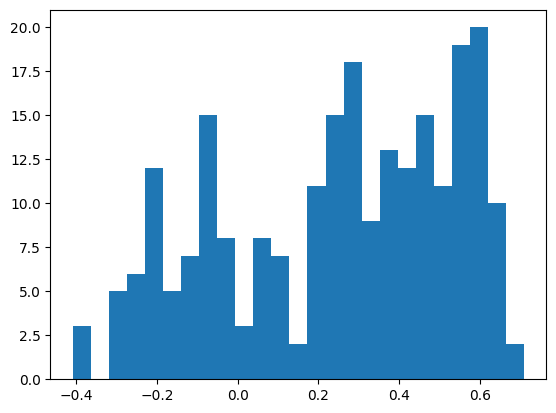

In [ ]:
comp1, comp2 = 'V','WBA'
corr, date = historicalCorrelation(ReturnMatrix, comp1, comp2)
edges = getEdgeList(comp1, comp2)
mu, std = scipy.stats.norm.fit(corr)
print('Mean: ',mu, "Std: ",std)
plt.hist(corr, bins=25)

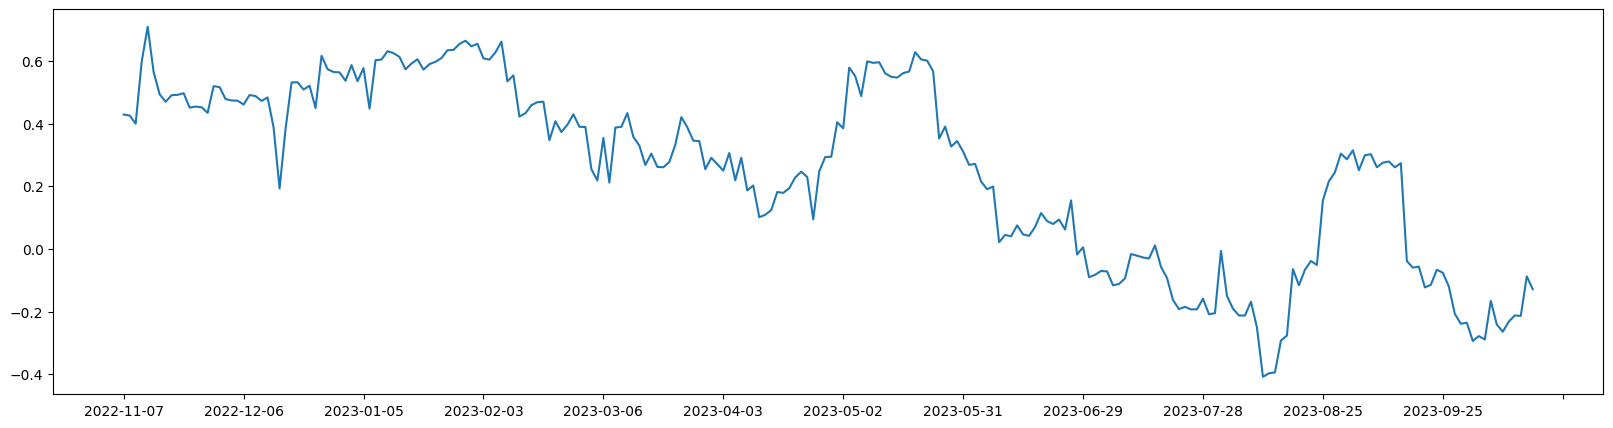

In [ ]:
plotHistoricalCorr(date, corr)

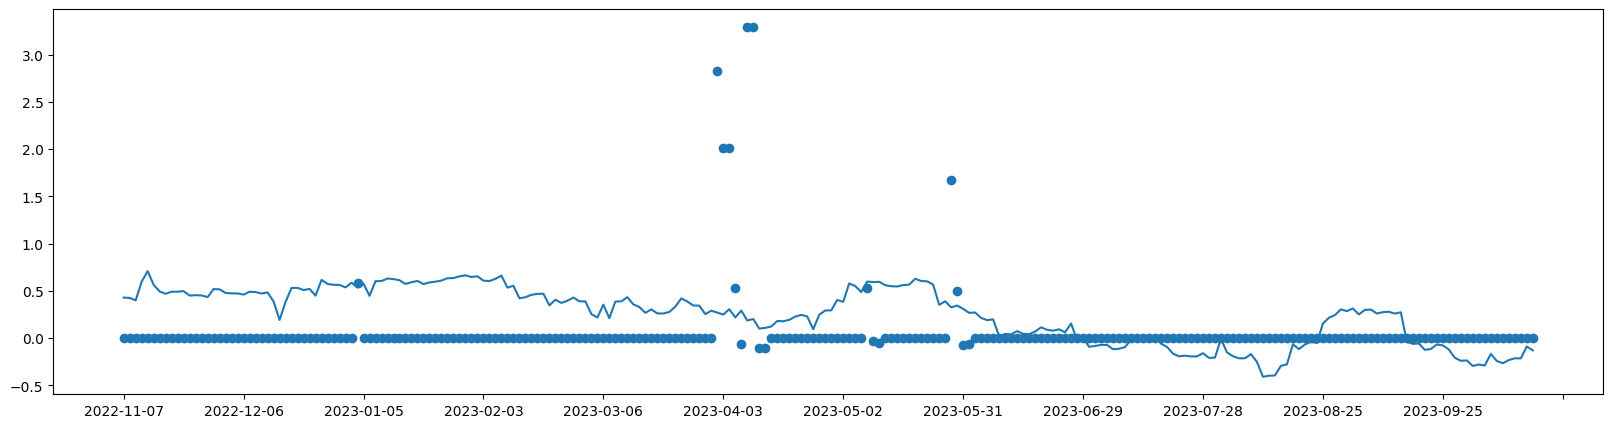

In [ ]:
plotEdge(date, edges, corr)

In [ ]:
DetectDrops(corr, edges)

Max Drop: 1.12, Std: 0.29
Event Drop: 0.16, Drop Rate: 0.14
Event Drop: 0.24, Drop Rate: 0.22
Event Drop: 0.11, Drop Rate: 0.10
Event Drop: 0.38, Drop Rate: 0.34


Mean:  0.8651426498714614 Std:  0.07554930842481382


(array([ 4.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  8.,  9., 10.,  2.,  9.,
         7.,  4.,  9., 11., 10., 12., 28., 27., 26., 23., 13., 21.]),
 array([0.60310644, 0.61752947, 0.63195251, 0.64637554, 0.66079857,
        0.6752216 , 0.68964463, 0.70406766, 0.71849069, 0.73291373,
        0.74733676, 0.76175979, 0.77618282, 0.79060585, 0.80502888,
        0.81945192, 0.83387495, 0.84829798, 0.86272101, 0.87714404,
        0.89156707, 0.90599011, 0.92041314, 0.93483617, 0.9492592 ,
        0.96368223]),
 <BarContainer object of 25 artists>)

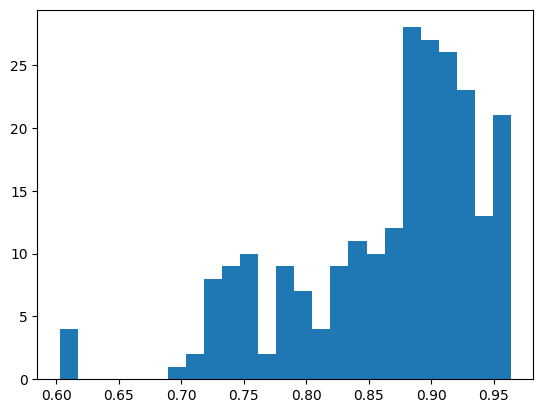

In [ ]:
comp1, comp2 = 'RSG','WM'
corr, date = historicalCorrelation(ReturnMatrix, comp1, comp2)
edges = getEdgeList(comp1, comp2)
mu, std = scipy.stats.norm.fit(corr)
print('Mean: ',mu, "Std: ",std)
plt.hist(corr, bins=25)

Max Drop: 0.36, Std: 0.08
Event Drop: 0.08, Drop Rate: 0.21
Event Drop: 0.08, Drop Rate: 0.23
Event Drop: 0.17, Drop Rate: 0.47
Event Drop: 0.23, Drop Rate: 0.64
Event Drop: 0.05, Drop Rate: 0.15
Event Drop: 0.11, Drop Rate: 0.32
Event Drop: 0.04, Drop Rate: 0.10
Event Drop: 0.09, Drop Rate: 0.26
Event Drop: 0.03, Drop Rate: 0.08
Event Drop: 0.21, Drop Rate: 0.58


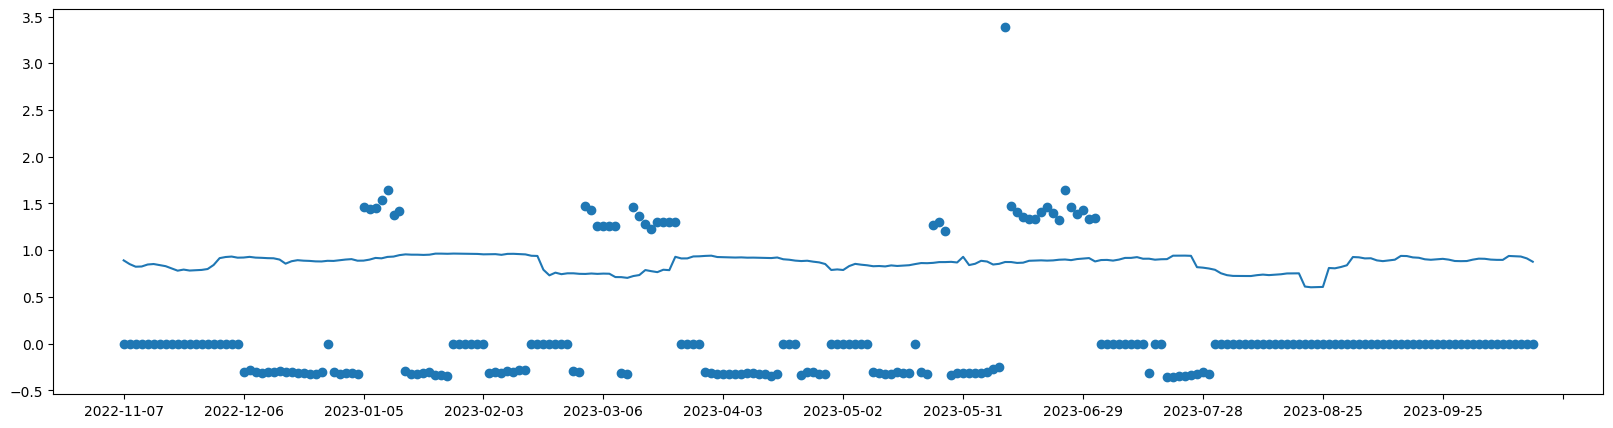

In [ ]:
plotEdge(date, edges, corr)
DetectDrops(corr, edges)

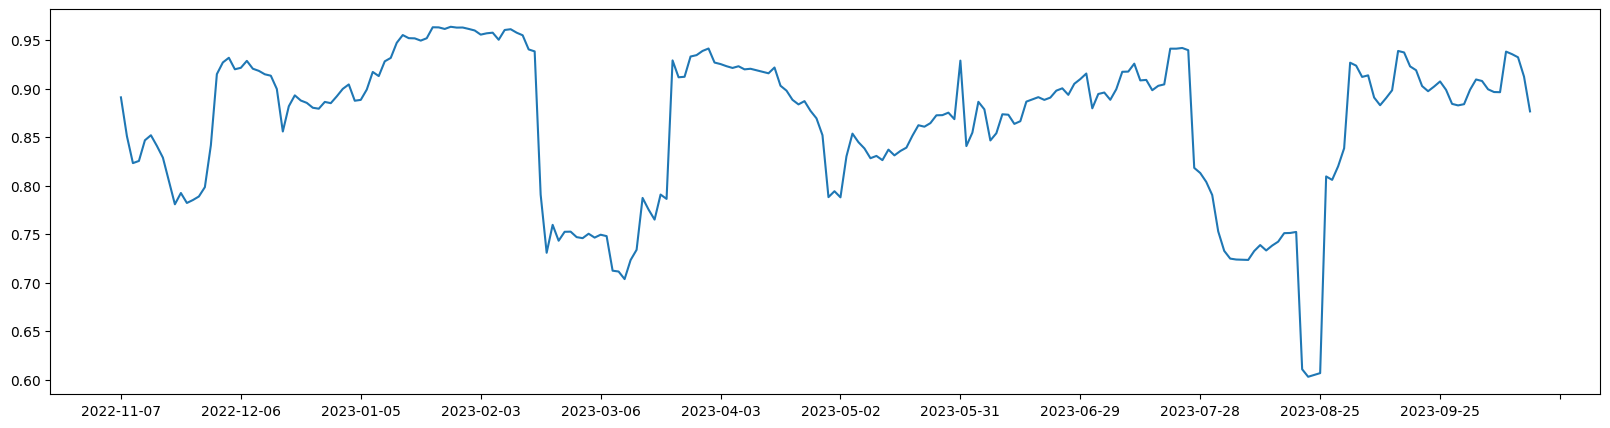

In [ ]:
plotHistoricalCorr(date, corr)

###
Through the above three examples, it is found that, in this dataset, companies are co-mentioned in different frequency which is reasonable. 

In the above example, company "V" and "WBA" are rarely co-mentioned in news. Thus, in most of times, there is no edge between node "V" and "WBA". However, "RSG" and "WH" usually being co-mentioned in news. So there is always an edge between these two companies nodes. In this case, should we statistically analyse the number of edges built between each pair of companies./  

In [22]:
comp_list = list(Comp_To_Node_Idx.keys())
comp_pair_list= list(itertools.combinations(comp_list, 2))
comp_pair_edges_dict = {}
for day in tqdm(range(LOOKBACK, len(dataset))):
    g = dataset[day]
    adj_matrix = EdgeIndex_To_AdjMatrix(graph=g, Comp_To_Node_Idx=Comp_To_Node_Idx)
    for pair in comp_pair_list:
        if pair not in comp_pair_edges_dict:
            comp_pair_edges_dict[pair] = []
        try:
            edge = adj_matrix[pair[0]].loc[pair[1]]
            comp_pair_edges_dict[pair].append(0) if np.isnan(edge) else comp_pair_edges_dict[pair].append(edge)
        except KeyError:
            comp_pair_edges_dict[pair].append(0)



100%|██████████| 236/236 [03:21<00:00,  1.17it/s]


(array([   0.,    0.,    0.,    0.,    0., 1782.,    0.,    0.,    0.,
           0.]),
 array([235.5, 235.6, 235.7, 235.8, 235.9, 236. , 236.1, 236.2, 236.3,
        236.4, 236.5]),
 <BarContainer object of 10 artists>)

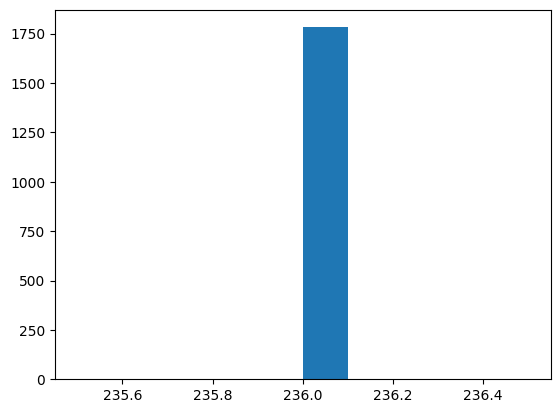

In [23]:
# for each company_pair, regard the number of edges during the period as a variable, and see the distribution
comp_pair_edges_count = []
for pair in comp_pair_edges_dict:
    if np.count_nonzero(comp_pair_edges_dict[pair]) != 0:
        comp_pair_edges_count.append(np.count_nonzero(comp_pair_edges_dict[pair]))
plt.hist(comp_pair_edges_count, bins=10)

模仿factor models，以graph中pair之间的edges建立一个新的factor，以此factor对相关性高，中，低的公司之间correlation， comovement的解释能力来作为评估graph edges的标准

1. 根据上图所示在时间段内两公司之间建立的edge的数量，随机抽取120个company-company pair（edges>0），将pair分为高，中， 低相关性三组
2. 计算每个company-company pair 的correlation/comovement，并且在每组内做平均
3. 构造factor， e.g. H-L
4. 另外随机抽取100个company-company pair， 按照edges数量排序并分为10组。计算每个company-company pair 的correlation/comovement，并且在每组内做平均。用步骤3构造的feature与每组的correlation/comovement作回归。观察Beta的变化是否与edge number的变化相关。


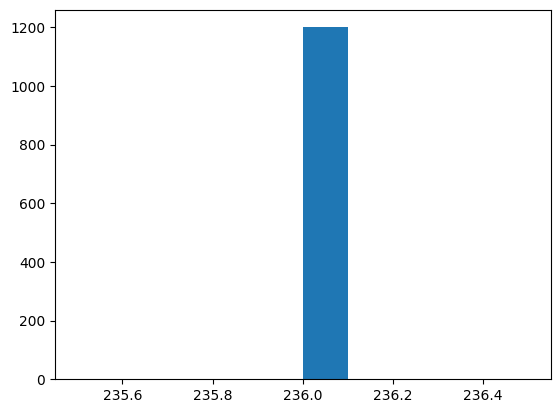

In [24]:
# from all companies pairs, find the pairs that has at least 1 edge
non_zero_pairs = []
non_zero_pair_edge = {}
for pair in comp_pair_edges_dict:
    if np.count_nonzero(comp_pair_edges_dict[pair]) > 0:
        non_zero_pairs.append(pair)
        non_zero_pair_edge[pair] = np.count_nonzero(comp_pair_edges_dict[pair]) 
# randomly sample 120 company pairs from non zero pairs, and also save their corresponding number of edges
random.seed(SEED)
pairs_120 = random.sample(non_zero_pairs, 1200)
edges_120 = []
for pair in pairs_120:
    edges_120.append(non_zero_pair_edge[pair])
plt.hist(edges_120, bins=10)
# based on the number of edges, split the 120 companies into high-correlated, medium-correlated, low-correlated companies. 

low_point, high_point = min(edges_120) + 0.3*(max(edges_120)-min(edges_120)), min(edges_120) + 0.7*(max(edges_120)-min(edges_120))
high_correlated_pairs = []
medium_correlated_pairs = []
low_correlated_pairs = []
for pair in pairs_120:
    if non_zero_pair_edge[pair] > high_point:
        high_correlated_pairs.append(pair)
    elif non_zero_pair_edge[pair] > low_point:
        medium_correlated_pairs.append(pair)
    else:
        low_correlated_pairs.append(pair)
# calculate the historical correlation of three group of companies
def getCorrelationMeanOfCompanyPairs(correlated_pairs, ReturnMatrix=ReturnMatrix):
    correlation_ts = []
    for pair in correlated_pairs:
        corr, _ = historicalCorrelation(ReturnMatrix, pair[0], pair[1])
        correlation_ts.append(corr)
    correlation_ts = np.array(correlation_ts)
    correlaion_mean_ts = np.mean(correlation_ts, axis=0)
    return correlaion_mean_ts

high_corr = getCorrelationMeanOfCompanyPairs(high_correlated_pairs)
medium_corr = getCorrelationMeanOfCompanyPairs(medium_correlated_pairs)
low_corr = getCorrelationMeanOfCompanyPairs(low_correlated_pairs)


In [27]:
low_point, high_point

(236.0, 236.0)

In [91]:
high_corr[:10], medium_corr[:10], low_corr[:10]

IndexError: invalid index to scalar variable.

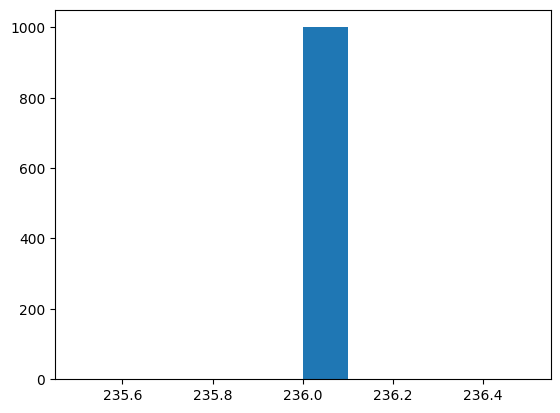

In [95]:
# randomly sample 100 company pairs from non zero pairs, and also save their corresponding number of edges
random.seed(SEED)
pairs_100 = random.sample(non_zero_pairs, 1000)
edges_100 = {}
for pair in pairs_100:
    edges_100[pair] = non_zero_pair_edge[pair]
plt.hist(edges_100.values(), bins=10)
# sorted the sampled 100 pairs by the number of edges
sorted_pairs = sorted(edges_100.items(), key=lambda x:x[1])
#split the pairs into 10 groups in the edge number ascending order
sorted_10_group_corrs = {}
for i in range(int(len(sorted_pairs)/100)):
    group = sorted_pairs[100*i:100*i+100]
    sorted_10_group_corrs[f'group_{i}'] = []
    for item in group:
        corr, _ = historicalCorrelation(ReturnMatrix, item[0][0], item[0][1])
        sorted_10_group_corrs[f'group_{i}'].append(corr)
    sorted_10_group_corrs[f'group_{i}'] = np.array(sorted_10_group_corrs[f'group_{i}'])
    sorted_10_group_corrs[f'group_{i}'] = np.mean(sorted_10_group_corrs[f'group_{i}'], axis=0)

In [96]:
factor = low_corr
sm.add_constant(factor)
betas = {}
for key in sorted_10_group_corrs:
    mod = sm.OLS(sorted_10_group_corrs[key], factor)
    res = mod.fit()
    betas[key] = res.params[0]
betas

{'group_0': 1.0957294083274616,
 'group_1': 0.9796216552544892,
 'group_2': 1.061857476392433,
 'group_3': 0.9651130281719604,
 'group_4': 0.9200483847678895,
 'group_5': 0.995133145232821,
 'group_6': 0.9934636422646639,
 'group_7': 1.065879845705475,
 'group_8': 0.9782620338281841,
 'group_9': 1.0180343690705516}

In [98]:
Delta_beta = np.mean(np.diff(list(betas.values())))
Delta_beta

-0.008632782139656668

###
group_0 到 group_9的beta有明显上升趋势，说明根据我们的graph edge density构造的factor high-low能够解释公司之间correlation的不同，能够反应公司与公司之间关系的差异性。

Correlation 只是一个指标，我们还可以需要考录其他的指标使得结论更robust
1. Look at the return_diff of each pair of companies. H1: the standard deviation of the return_diff of highly correlated companies tends to be low, the standard deviation of the return_diff of not related companies tends to be high. 

2. DCC-GARCH（Dynamic Conditional Correlations GARCH）模型是一种多元时间序列模型，用于研究多个金融资产的波动率变化与相关性。该模型采用GARCH模型（广义自回归条件异方差模型）作为基本框架，并引入动态相关系数的概念。

In [99]:
# calculate the historical return_difference of three group of companies
def historicalReturnDiffDiff(ReturnMatrix, comp1, comp2):
    """
    Input: ReturnMatrix, the company tickers of the two company to calculate
    Output: the return difference of the two companies
    """
    date = []
    diff = []
    for i in range(1,ReturnMatrix.shape[0]-LOOKBACK):
        # diff.append(ReturnMatrix[comp1].iloc[i] - ReturnMatrix[comp1].iloc[i-1] - (ReturnMatrix[comp2].iloc[i] - ReturnMatrix[comp2].iloc[i-1]))
        diff.append(min(ReturnMatrix[comp1].iloc[i]-ReturnMatrix[comp2].iloc[i],abs(ReturnMatrix[comp1].iloc[i])-abs(ReturnMatrix[comp2].iloc[i])))
        date.append(ReturnMatrix.index[i+LOOKBACK])
    diff = np.array(diff)
    return diff, date

def getReturnDiffMeanOfCompanyPairs(correlated_pairs, ReturnMatrix=ReturnMatrix):
    diff_ts = []
    for pair in correlated_pairs:
        diff, _ = historicalReturnDiffDiff(ReturnMatrix, pair[0], pair[1])
        diff_ts.append(diff)
    diff_ts = np.array(diff_ts)
    # diff_mean_ts = np.mean(diff_ts, axis=0)
    return diff_ts

high_diff = getReturnDiffMeanOfCompanyPairs(high_correlated_pairs)
medium_diff = getReturnDiffMeanOfCompanyPairs(medium_correlated_pairs)
low_diff = getReturnDiffMeanOfCompanyPairs(low_correlated_pairs)

print(np.std(high_diff), np.std(medium_diff), np.std(low_diff))

nan nan 0.017739886054085354


In [22]:
high_diff

array([[-0.02336111, -0.00411951,  0.00934953, ..., -0.00301163,
        -0.0414915 , -0.00896027],
       [-0.00207141, -0.00501064, -0.01162786, ..., -0.00108593,
        -0.01297897,  0.00091177],
       [-0.01448465,  0.00369047,  0.02392147, ..., -0.00880467,
        -0.00215542,  0.00384207],
       [-0.01850536, -0.00435172, -0.00186908, ..., -0.00398948,
        -0.00937783, -0.02691029],
       [-0.06561912, -0.02335984, -0.00410543, ..., -0.00674582,
         0.0089209 , -0.01218589],
       [-0.00285447, -0.01245778, -0.02405355, ..., -0.00747984,
        -0.00146974,  0.00725735]])

In [100]:
# leverage DCC-GARCH model to evaluate whether the high_correlated_pairs tends to have a high dynamic correlation coefficient（DCC)

from DCC_GARCH.GARCH.GARCH import GARCH
from DCC_GARCH.GARCH.GARCH_loss import garch_loss_gen
from DCC_GARCH.DCC.DCC import DCC
from DCC_GARCH.DCC.DCC_loss import dcc_loss_gen


In [101]:
def dcc_garch(comp1, comp2):
    """
    Given a pair of companies, return the coefficient a, b of DCC GARCH model.
    """

    c1_garch_model = GARCH(1,1)
    c1_garch_model.set_loss(garch_loss_gen(1,1))
    c1_garch_model.set_max_itr(1)
    c1_return = ReturnMatrix[comp1].iloc[::-1]
    c1_garch_model.fit(c1_return)

    c2_garch_model = GARCH(1,1)
    c2_garch_model.set_loss(garch_loss_gen(1,1))
    c2_garch_model.set_max_itr(1)
    c2_return = ReturnMatrix[comp2].iloc[::-1]
    c2_garch_model.fit(c2_return)

    c1_sigma = c1_garch_model.sigma(c1_return)
    c1_epsilon = c1_return / c1_sigma

    c2_sigma = c2_garch_model.sigma(c2_return)
    c2_epsilon = c2_return / c2_sigma

    epsilon = np.array([c1_epsilon, c2_epsilon])

    dcc_model = DCC()
    dcc_model.set_loss(dcc_loss_gen())
    dcc_model.fit(epsilon)

    return dcc_model.get_ab()

def group_dcc_garch(group):
    """
    Input: group of pairs
    Output: a, b of each pair
    """
    group_ab= []
    for pair in group:
        try: 
            ab = dcc_garch(pair[0],pair[1])
        except np.linalg.LinAlgError:
            pass
        group_ab.append(ab)
    
    return group_ab


In [ ]:
dcc_garch('PXD', 'DVN')

array([ 2.32693123e-01, -3.54377188e-17])

In [106]:
high_ab = group_dcc_garch(high_correlated_pairs)
medium_ab = group_dcc_garch(medium_correlated_pairs)
low_ab = group_dcc_garch(low_correlated_pairs)
high_ab

In [26]:
medium_ab

[array([0.60396479, 0.39603698]),
 array([0.01771718, 0.95908014]),
 array([0.0385931 , 0.73852098]),
 array([-1.17757359e-09,  8.12661816e-01]),
 array([0.02278477, 0.86711764]),
 array([-2.69329004e-12,  9.01683431e-01]),
 array([0.05544509, 0.75049847]),
 array([1.04484754e-11, 7.82699184e-01]),
 array([0.0287725 , 0.82913682]),
 array([-5.19057020e-12,  8.96639713e-01]),
 array([0.70623534, 0.29449305]),
 array([0.01026235, 0.98973765]),
 array([-1.46325729e-11,  8.96719922e-01]),
 array([2.54672949e-11, 7.80452513e-01]),
 array([ 1.98834934e-01, -8.43286473e-19]),
 array([0.85055291, 0.14890338]),
 array([0.13268844, 0.6229964 ]),
 array([0.01013689, 0.88139023]),
 array([0.00368793, 0.99631273]),
 array([0.19062752, 0.64410423]),
 array([1.04584114e-09, 7.86403644e-01]),
 array([0.01967783, 0.97733596]),
 array([0.18936399, 0.60917235]),
 array([0.12552587, 0.87447413]),
 array([0.00648661, 0.97733054]),
 array([-1.25797150e-11,  7.90981405e-01]),
 array([0.06522477, 0.91516557])

In [32]:
np.average(high_ab, axis=0), np.average(medium_ab, axis=0), np.average(low_ab, axis=0)

(array([0.17382813, 0.67636281]),
 array([0.1169212, 0.7154155]),
 array([0.11005482, 0.72483666]))

In [136]:
li = []
for i in low_ab:
    li.append(sum(i))
print(np.mean(li))

0.8348914738811982


In [121]:
non_zero_pair_edge[('PXD', 'DVN')]

192

In [ ]:
df = pd.DataFrame(np.array([corr_HIG_AON, edges_HIG_AON]).T, columns=['corr','edge'])
df.to_csv('../outputs/HIG_AON_corr_edge.csv',)

In [35]:
adjmatrix = EdgeIndex_To_AdjMatrix(dataset[0], Comp_To_Node_Idx)
for col in adjmatrix.columns:
    for row in adjmatrix.index:
        if np.isnan(adjmatrix[col].loc[row]):
            pass
        else:
            print(col, row, adjmatrix[col].loc[row])

HIG PRU -0.3527738189332855
HIG AON -0.3527738189332855
RSG JBHT -0.3527738189332855
RSG WM -0.3527738189332855
BK STT 1.1683155407931005
BK MCO -0.3527738189332855
MAT KIM -0.3527738189332855
MAT EMR -0.3527738189332855
MAT MCD -0.3527738189332855
MAT ORCL -0.3527738189332855
MAT DAL -0.3527738189332855
MAT SYY -0.3527738189332855
MAT AAL -0.3527738189332855
MAT CMCSA -0.3527738189332855
MAT PM -0.3527738189332855
MAT JWN -0.3527738189332855
MAT ED -0.3527738189332855
MAT INTU -0.3527738189332855
MAT CCI -0.3527738189332855
MAT BXP -0.3527738189332855
MAT HAS -0.3527738189332855
MAT T -0.3527738189332855
MAT GPS -0.3527738189332855
MAT CPB -0.3527738189332855
MAT NAVI 1.1683155407931005
TSCO DE -0.3527738189332855
TSCO ADM -0.3527738189332855
TSCO TSN -0.3527738189332855
WBA ABC -0.3527738189332855
WBA ABT -0.3527738189332855
WBA INTC -0.3527738189332855
WBA JNJ -0.3527738189332855
WBA GPS -0.3527738189332855
WBA CVS -0.3527738189332855
WBA V -0.3527738189332855
AVB CFG -0.35277381893

# + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + 

In [ ]:
idx = torch.multinomial(G_t_node_idx.float(), num_samples=50)
VisualizeGraphDataset(dataset, day=day_t, subgraph=G_t.subgraph(idx))

In [ ]:
temp_G = G_t.subgraph(idx)
s, t = temp_G.edge_index[:,0]
temp_G

In [ ]:

EdgeIndex_To_AdjMatrix(graph=temp_G,Comp_To_Node_Idx=Comp_To_Node_Idx)

In [ ]:
corr_HIG_DFS, date = historicalCorrelation(ReturnMatrix, 'HIG','DFS')
params = scipy.stats.norm.fit(corr_HIG_DFS)
plt.hist(corr_HIG_DFS, bins=30)

In [ ]:
plotHistoricalCorr(date, corr_HIG_DFS)

In [ ]:
EdgeIndex_To_AdjMatrix(temp_G, Comp_To_Node_Idx)['HIG'].loc['DFS']

In [ ]:
corr_MAT_VTR,date = historicalCorrelation(ReturnMatrix, 'MAT','VTR')
plotHistoricalCorr(date, corr_MAT_VTR)

In [ ]:
corr_MAT_DFS, date = historicalCorrelation(ReturnMatrix, 'MAT','DFS')
plotHistoricalCorr(date, corr_MAT_DFS)

In [1]:
import pandas as pd

In [18]:
a = pd.DataFrame({
    'ISIN':['A','B','C'],
    'Date':[1,1,2],
    'Price':[0.1,0.2,0.3]
})
b = pd.DataFrame({
    'ISIN':['C','C','D','E','F'],
    'Date':[2,1,2,2,2],
    'Price':[0.1,0.6,0.2,0.3, 0.4]
})
a

,ISIN,Date,Price
0,A,1,0.1
1,B,1,0.2
2,C,2,0.3


In [19]:
b

,ISIN,Date,Price
0,C,2,0.1
1,C,1,0.6
2,D,2,0.2
3,E,2,0.3
4,F,2,0.4


In [27]:
c = pd.merge(a, b, how='left', on='ISIN', indicator=True).query('_merge=="left_only"')
c

,ISIN,Date_x,Price_x,Date_y,Price_y,_merge
0,A,1,0.1,NaN,NaN,left_only
1,B,1,0.2,NaN,NaN,left_only


In [30]:
pd.concat([c, b], axis=1).query('Date_x==1.0').query('Price_x==0.1')

,ISIN,Date_x,Price_x,Date_y,Price_y,_merge,ISIN,Date,Price
0,A,1.0,0.1,NaN,NaN,left_only,C,2,0.1


In [46]:
from utils import YToThreeClasses
out = [0,0,0]
for i in range(len(dataset)):
    a = YToThreeClasses(dataset[i])
    zero = torch.sum(a==0)
    one = torch.sum(a==1)
    two = torch.sum(a==2)
    out[0]+= zero
    out[1]+= one
    out[2]+= two
print(out)

[tensor(18190), tensor(75715), tensor(17293)]
